In [2]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
import random 
random.seed(3)
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [114]:
# bramble-1-1 39
# bramble-1-3 38
# bramble-1-4 39
# bramble-2-1 23
# bramble-2-2 41
# bramble-2-4 39
# bramble-2-5 38
# bramble-2-6 35
# bramble-4-1 36
# bramble-4-2 0
# bramble-4-3 26
# bramble-4-5 38
# bramble-4-6 32

total_flops_map = {"resnet18": 3628146688, "tcn": 21525774336, "vit":33697001472}

def tf_calc(w, n):
    y=0
    if w < 8:
        y = 0.157 - 0.004*n + 0.075*w
    else:
        y = 0.667 - 0.008*n + 0.023*w
    return y

def constrained_sum_sample_pos(n, total):
    """Return a randomly chosen list of n positive integers summing to total.
    Each such list is equally likely to occur."""

    dividers = sorted(random.sample(range(10, total), n - 1))
    return [a - b for a, b in zip(dividers + [total], [0] + dividers)]

def constrained_sum_sample_nonneg(n, total):
    """Return a randomly chosen list of n nonnegative integers summing to total.
    Each such list is equally likely to occur."""
    return [x - 1 for x in constrained_sum_sample_pos(n, total + n)]


def time_predictor(peak_times, fp, bg_load=0):
    maybe_gnt = [0]*len(peak_times)
    achieved_fps = [i for i in peak_times]
    if len(peak_times)==1:
        return achieved_fps

    for ind, i in enumerate(peak_times):
        # if (i-maybe_bnt[ind]) > 0 and len(peak_times)-ind>0:
        #     bnt = (i-maybe_bnt[ind])*tf_calc(len(peak_times)-ind, 38) + (i-maybe_bnt[ind]) #if tf = (t-p)/p
        #     for k in range(ind, len(maybe_bnt)):
        #         maybe_bnt[k] = maybe_bnt[k]+bnt
        # else:
        #     bnt = (i-maybe_bnt[ind])*tf_calc(len(peak_times)-ind, 38) + (i-maybe_bnt[ind])
            # print(bnt)
        if (i-maybe_gnt[ind]) > 0 and len(peak_times)-ind>0:
            val = tf_calc(len(peak_times)-ind+bg_load, 38)
            # print(val, bg_load)
            val = val if val < 1 else 0.99
            gnt = (i-maybe_gnt[ind])/(1-val) #if tf = (t-p)/t
            for k in range(ind, len(maybe_gnt)):
                maybe_gnt[k]=maybe_gnt[k]+gnt
                achieved_fps[k] = fp[k]*maybe_gnt[ind]/fp[ind] + (fp[k]-fp[ind])*peak_times[ind]/fp[ind]
        # else:
        #     gnt = (i-maybe_gnt[ind])/(1-tf_calc(len(peak_times)-ind, 38))
    return achieved_fps

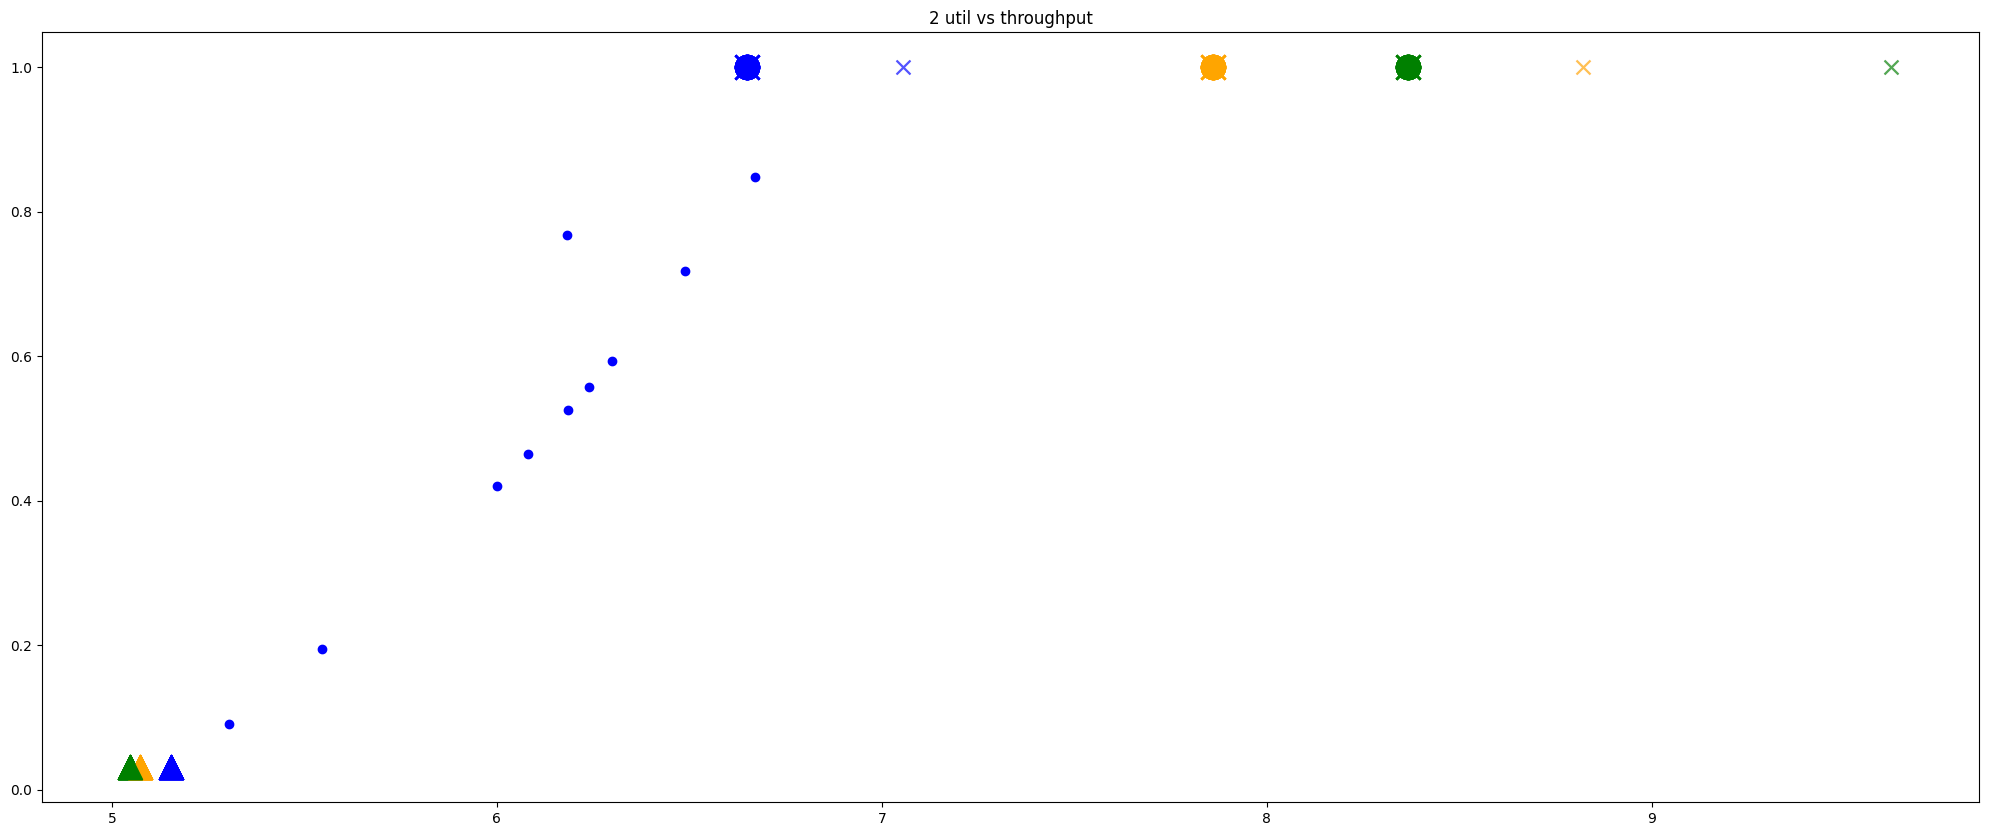

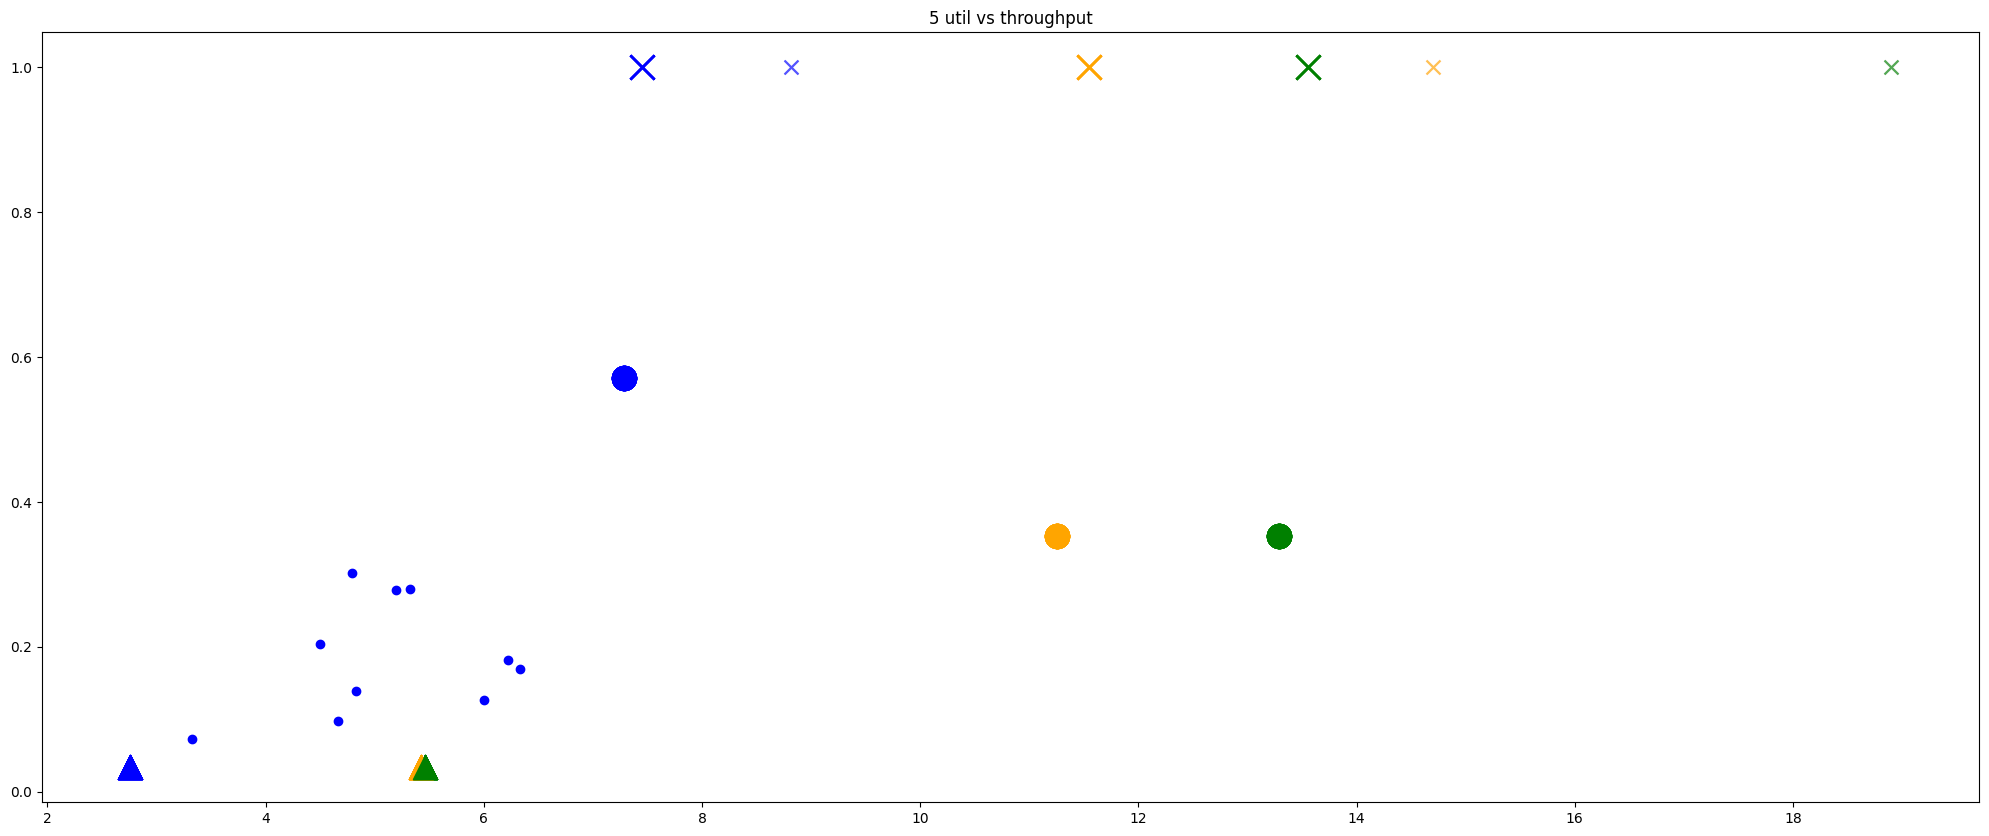

In [115]:
def bn_calc(fp, bn, fixed_iters=1, peak_rate=4.8, bg_load=0):
    og_fp =[f for f in fp]
    fp = [f for f in sorted(fp)]
    # og_fp = sorted(fp, reverse=True)
    # og_fp = sorted(fp)
    

    # og_fp = fp[:len(fp)//2] + [max(fp)]
    # c=0
    # for f in sorted(fp[len(fp)//2:],reverse=True):
    #     if c==0 and f==max(fp):
    #         c+=1
    #         continue
    #     og_fp.append(f)
    # print(fp, og_fp)
    
    # og_fp = og_fp + [f for f in fp if fp not in og_fp]
    throttled_latency = 0
    peak_latency = 0
    min_util = np.inf
    back_col=0
    for col in range(bn+len(fp)-1):
        slice_fp=[]
        if col < bn:
            slice_fp = og_fp[:col+1]
        if col >= bn:
            slice_fp = og_fp[back_col+1:]
            back_col+=1
        slice_fp = sorted(slice_fp)
        slice_pt = [f*fixed_iters*10**-3/peak_rate for f in slice_fp]
        tf=0
        # if max(slice_fp) == min(slice_fp) and len(slice_fp)>1:
        #     #even split case
        #     tf = tf_calc(len(slice_fp), 38) #hardcoding 38 for now
        #     time_list = [s_pt/(1-tf) for s_pt in slice_pt]
        # else:
        time_list = time_predictor(slice_pt, slice_fp, bg_load)
        # if bn==5:
        # print(time_list, col, fp, bn, slice_fp, bg_load)
        # print(time_list)
        throttled_latency += max(time_list)
        peak_latency += max(slice_pt)
        min_util = min(min(time_list)/max(time_list), min_util)
    return throttled_latency, min_util, peak_latency
    
#for resnet make util vs throttle fraction graph ? 
#is this throttle fraction end to end ? or do we want to make this slow down?
splits = [2,5]
fixed_iters = 1 #batch_size = 4*1
peak_rate = 4.8 #gflop/s
#network throttling? -> check with a subcluster how much overhead does this actually have?
random.seed(3)
bn_color_map = {2:"blue", 5:"orange", 10:"green"}
batch_nums = list(bn_color_map.keys())
model="resnet18"
# model="vit"
# model="tcn"
for world in splits:
    fig, axs = plt.subplots(figsize=(25,10))
    visited_trials=[]
    x=[] #slow down
    y=[] #util
    for trial in range(10):
    # for bn in batch_nums:
        fp = sorted(constrained_sum_sample_pos(world, round(total_flops_map[model]*10**-6)))
        peak_times = [f*fixed_iters*10**-3/peak_rate for f in fp]
        if fp not in visited_trials:
            visited_trials.append(fp)

        # for trial in range(1):
        for bn in batch_nums:
            img_procs = bn*fixed_iters*4
            #ten points on the pareto curve
            # back_fp = fp * bn
            # back_pt = peak_times * bn
            
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)

            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn])

            #special cases:
            #all equal split
            fp = [round(total_flops_map[model]*10**-6)/world]*world
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)
            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn], marker="x", s=300)
            axs.scatter(img_procs/peak_latency, min_util, color=bn_color_map[bn], alpha=0.1, marker="x", s=100)

            #fully unbalanced
            fp = [100]*(world-1) + [round(total_flops_map[model]*10**-6) - 100*(world-1)]
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)
            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn], marker="^", s=300)

            #ideal unbalanced
            h=round(total_flops_map[model]*10**-6)/world
            l= (world-1)*round(total_flops_map[model]*10**-6)/world
            fp = [ (l/(sum( range(1, world))))*i for i in range(1,world) ] + [h]
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate)
            # print(fp, throttled_latency)

            axs.scatter(img_procs/throttled_latency, min_util, color=bn_color_map[bn], marker="o", s=300)
        # raise Exception("end it here")
            # x.append(img_procs/throttled_latency)
            # y.append(min_util)
        # axs.scatter(x,y)
    axs.set_title(f"{world} util vs throughput")

    
        

                





            

            









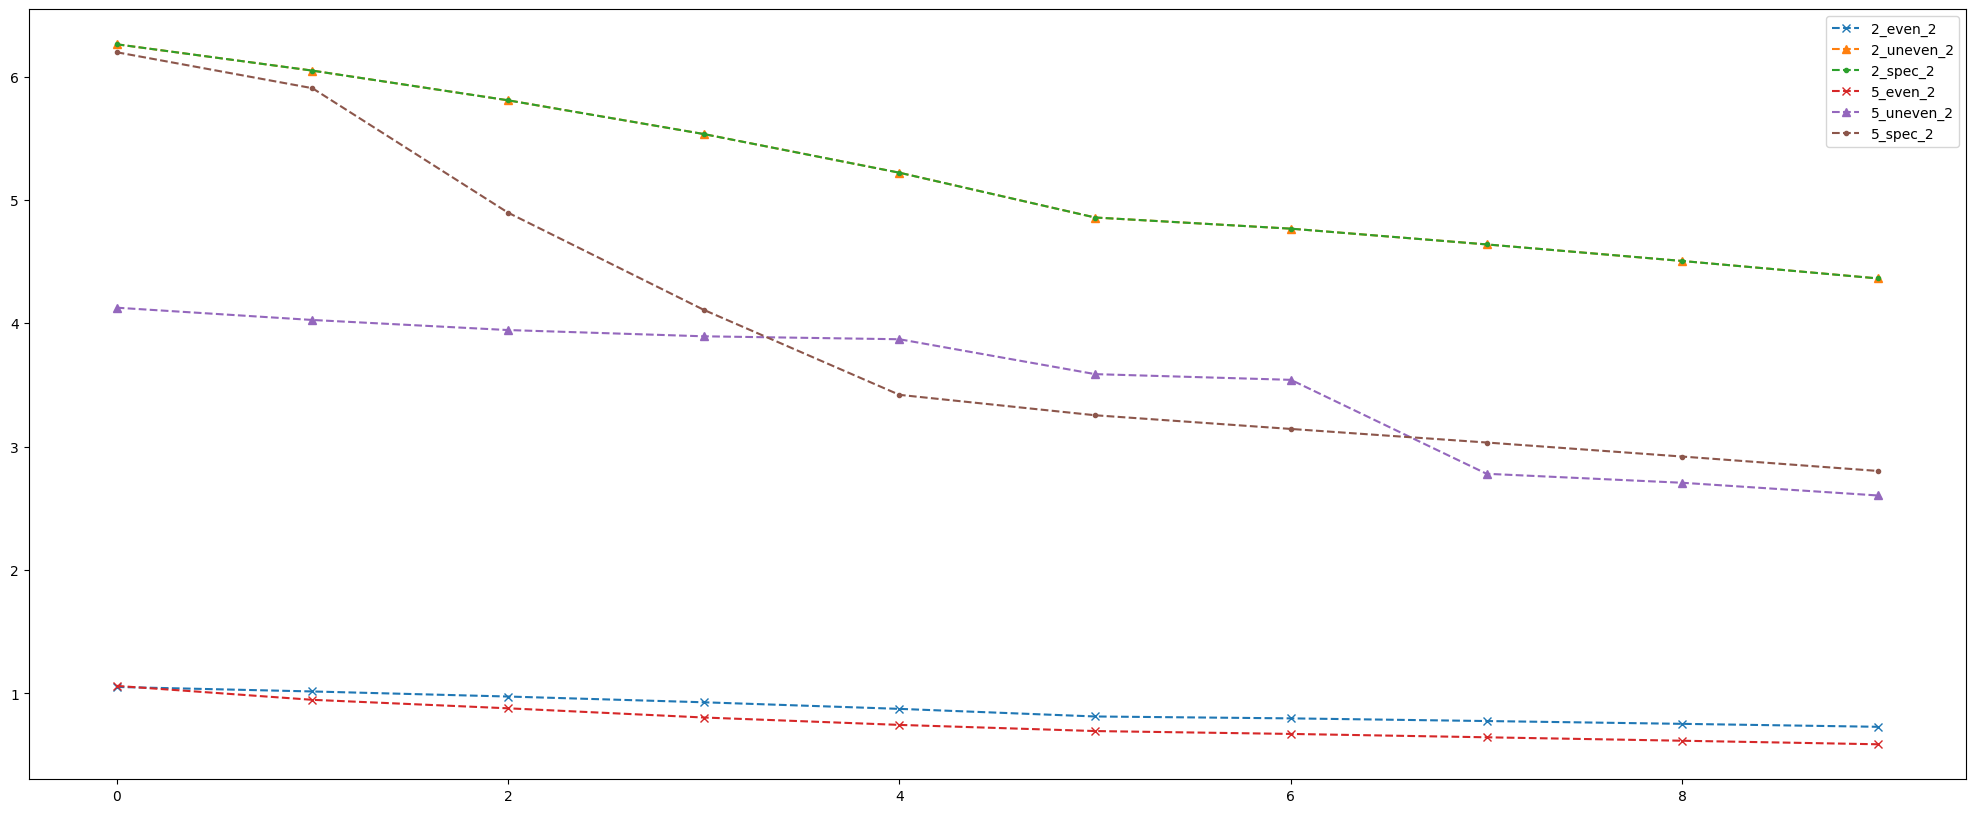

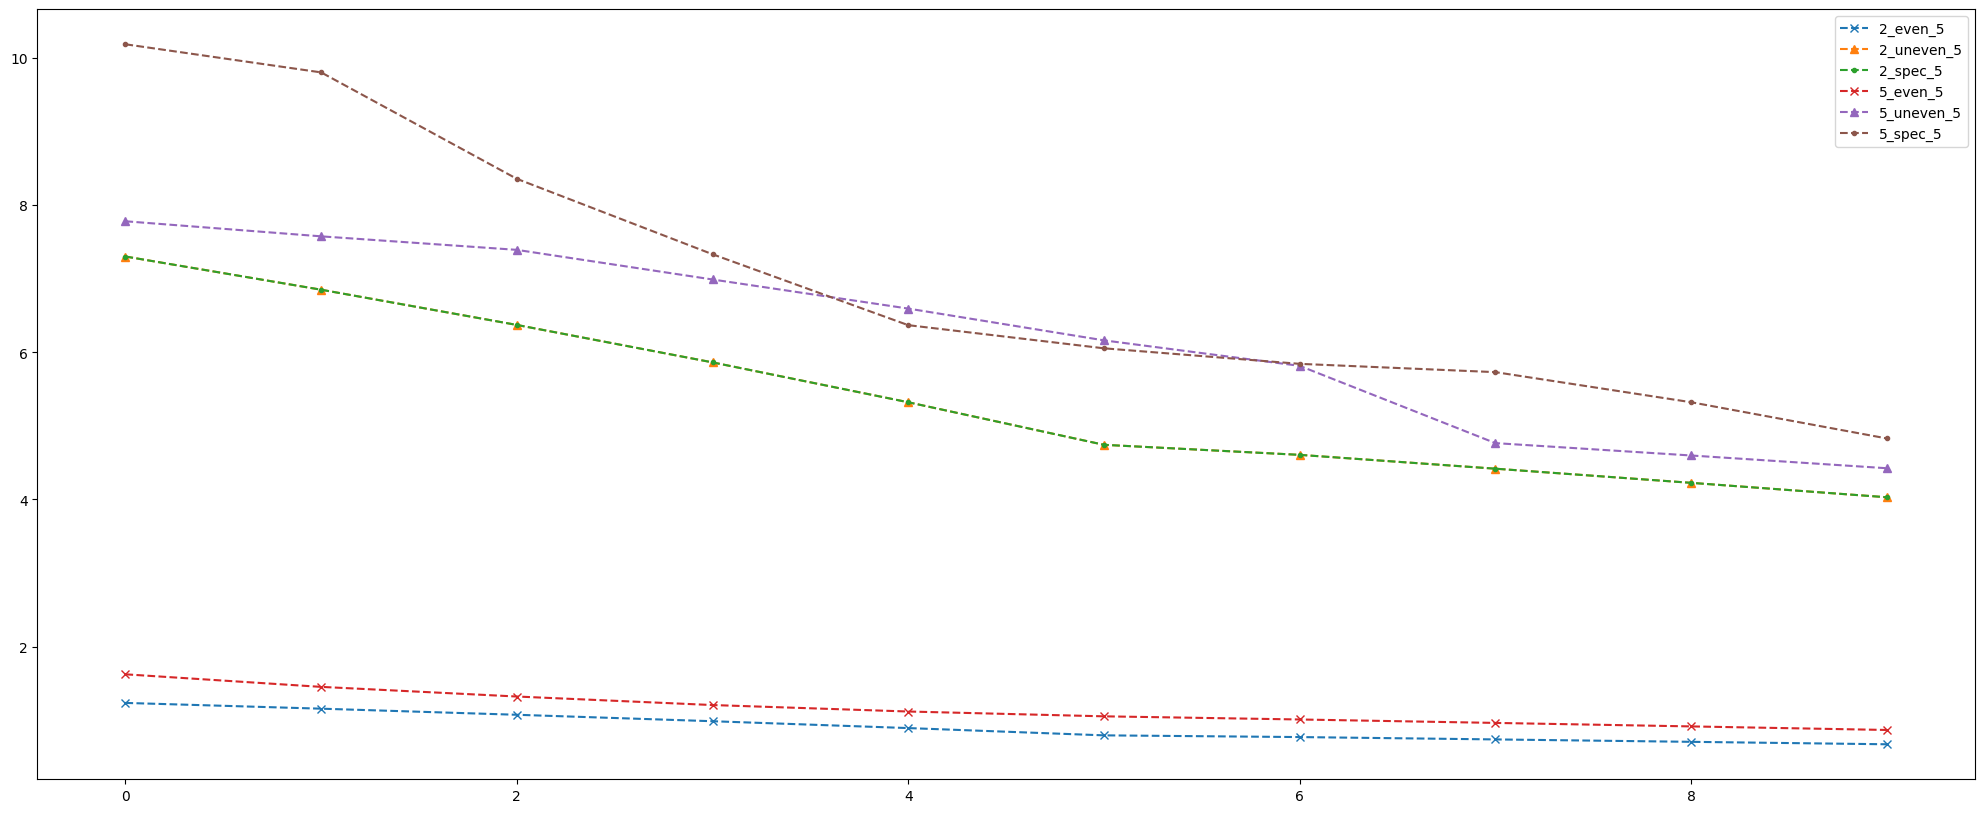

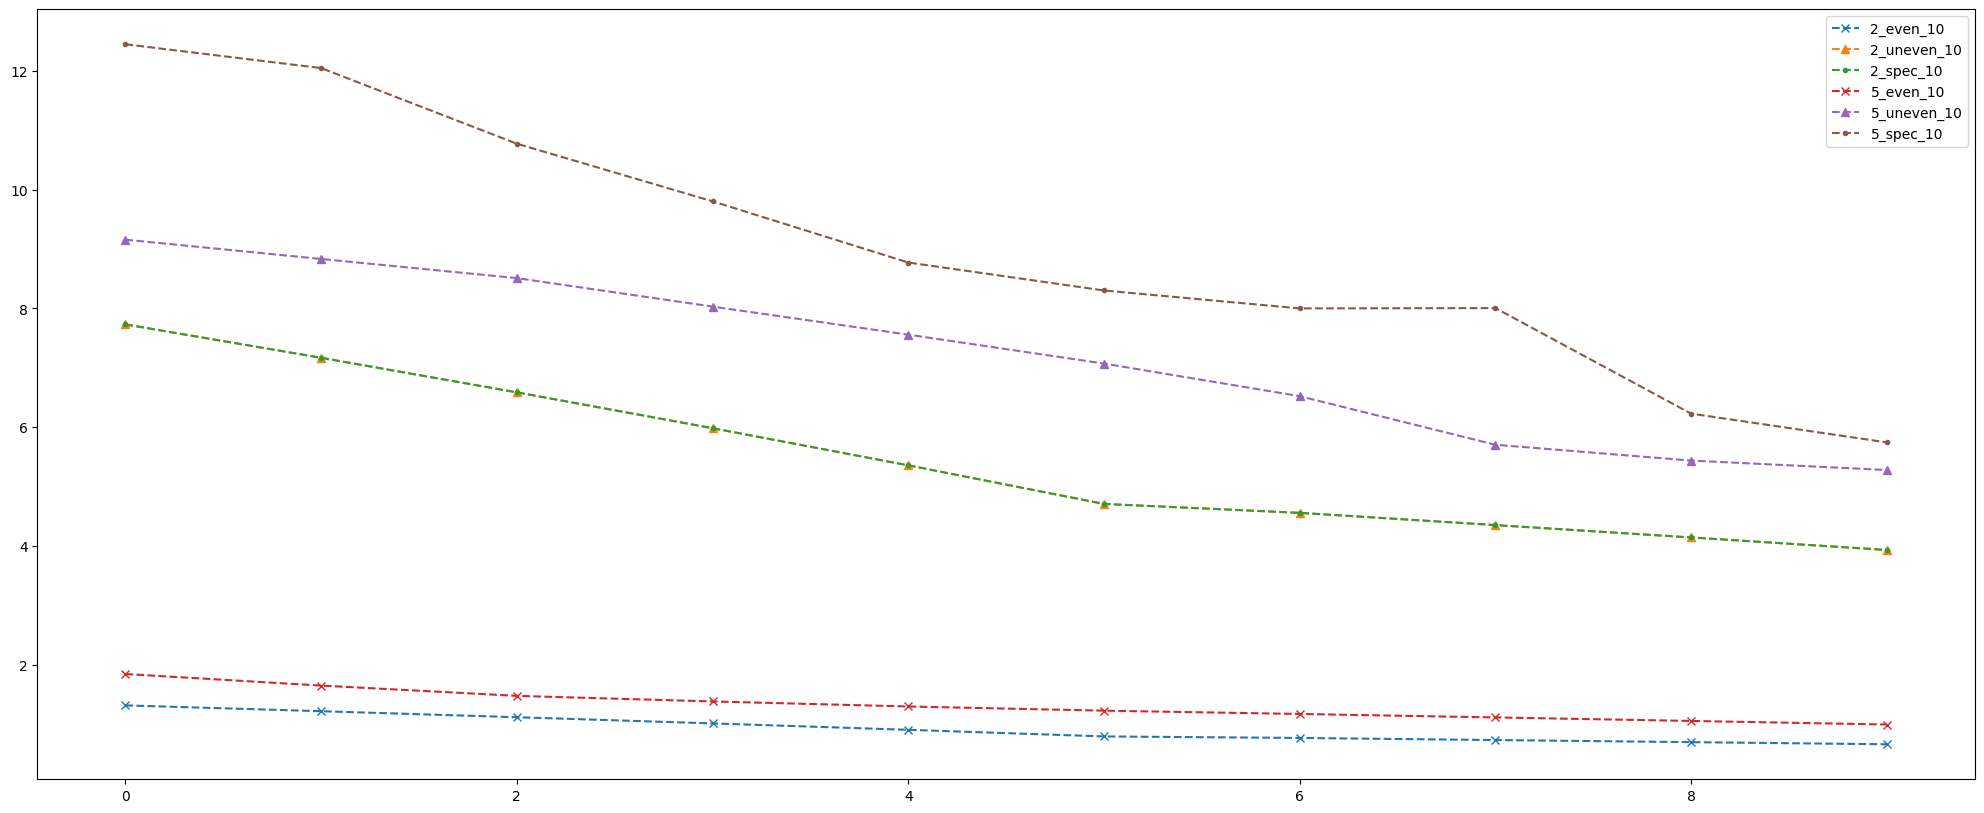

In [127]:
import maybe_broken as mb
import tcn_library

#for resnet
from torchvision.models import resnet18
# print("Testing with ResNet18:")
model = resnet18(weights=None)
model.eval()
res_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))

model = tcn_library.SensorTCN(
            num_channels=8,
            hidden_channels=256,
            levels=8,
            kernel_size=5,
            output_channels=8,
        ).eval()

tcn_splitter = mb.ModelSplitter(model, input_shape=(1,2048,8))

from torchvision.models import vision_transformer
model = vision_transformer.vit_b_16(weights=None)
model.eval()
vit_splitter = mb.ModelSplitter(model, input_shape=(1, 3, 224, 224))

lines={2:[],5:[],10:[]}
ax_map = {2:[],5:[],10:[]}
for bn in lines:
    fig, axs = plt.subplots(figsize=(25,10))
    ax_map[bn] = [fig, axs]

for world in [2,5]:
    visited=[]
    even_lines={2:[],5:[],10:[]}
    uneven_lines={2:[],5:[],10:[]}
    spec_lines={2:[],5:[],10:[]}
    
    # for trial in range(10):
    #     mixture = constrained_sum_sample_pos(world, 100)
    #     if mixture not in visited:
    #         visited.append(mixture)
    #     results = res_splitter.split(mixture)
    #     fp = [r['actual_flops']*fixed_iters*10**-9 for r in results['splits']]
    #     nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    #     tnw = [ (10**-2)*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
        
    #     for bn in lines.keys():
    #         img_procs = bn*fixed_iters*4
    #         for b in range(10):
    #             throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
    #             lines[bn].append(img_procs/throttled_latency)
        
    #spec lines
    #even split
    mixture = [100/world]*world
    # results = res_splitter.split(mixture)
    # results = tcn_splitter.split(mixture)
    results = vit_splitter.split(mixture)
    # results = res_splitter.split(mixture)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    tnw = [ (10**-2)*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        for b in range(10):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            even_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))

    #uneven split
    # mixture = [10/(world-1)]*(world-1)+[90] #-> worst version
    mixture = [50*i/(sum(range(1,world))) for i in range(1,world)] + [50]
    results = res_splitter.split(mixture)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    tnw = [ (10**-2)*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        for b in range(10):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            uneven_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
    
    #ideal uneven split?
    mixture = [100*(world-1)*i/(world*sum(range(1,world))) for i in range(1,world)] + [100/world]
    results = res_splitter.split(mixture)
    fp = [r['actual_flops']*fixed_iters*10**-6 for r in results['splits']]
    nw = [r["layers"][-1]['output_shape'] for r in results['splits']]
    tnw = [ (10**-2)*np.empty(tuple(r), dtype=np.float32).nbytes*8/10**6 for r in nw]
    for bn in lines.keys():
        img_procs = bn*fixed_iters*4
        for b in range(10):
            throttled_latency, min_util, peak_latency = bn_calc(fp, bn,  fixed_iters, peak_rate, bg_load=b)
            spec_lines[bn].append(img_procs/(throttled_latency+sum(tnw[:-1])))
    # for bn in lines:
    #     axs.scatter(, alpha=0.2, color=bn_color_map[bn])
    for bn in lines:
        # fig, axs = plt.subplots(figsize=(25,10))
        axs = ax_map[bn][1]
        axs.plot(np.arange(0,10,1), even_lines[bn], marker="x", linestyle="--", label=f"{world}_even_{bn}")
        axs.plot(np.arange(0,10,1), uneven_lines[bn], marker="^", linestyle="--", label=f"{world}_uneven_{bn}")
        axs.plot(np.arange(0,10,1), spec_lines[bn], marker=".", linestyle="--", label=f"{world}_spec_{bn}")
        axs.legend()
        # break
    # axs.legend()
        # break
    # break
        # axs.plot(np.arange(0,11,1), even_lines[bn])
# results = splitter.split([30, 33, 11, 18, 8])
# fp = 
# for r in results["splits"]:
#     last_layer = r["layers"][-1]

#     print(r['actual_flops'], np.empty(tuple(last_layer["output_shape"]), dtype=np.float32).nbytes*8/10**6)
